# IIoT Network Analysis: Age of Information and Reliability Trade-offs

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf

In [2]:
# Load the dataset
df = pd.read_csv('iiot_network_data.csv')

# 1. Conceptual Understanding (20 points)

"""
Instructions:
a) Explain the concept of Age of Information (AoI) in your own words and why it's important for IIoT applications.
b) Describe the difference between AoI-oriented traffic and deadline-oriented traffic in IIoT networks. Provide real-world examples for each.

Write your answers here:

a) Age of Information (AoI) explanation:

I think of Age of Information (AoI) as a "freshness" meter for data. It is basically the amount of time that has passed since the latest piece of information was actually generated by a sensor. It is different from regular network delay because it does not just care about how fast a packet travels; it cares about how "stale" the information is by the time the controller looks at it.

This is really important for IIoT because industrial systems usually rely on constant status updates to work correctly. If a controller is making decisions based on data that is even a few seconds old, it is working with "stale" information, which can lead to serious mistakes or safety hazards. For example, imagine a sensor monitoring the pressure in a steam pipe. If the pressure is spiking and the controller gets an update that is 5 minutes old saying "everything is fine," it might not trigger the safety valve in time to prevent a burst.



b) AoI-oriented vs deadline-oriented traffic:

From what I gathered in the paper, the main difference comes down to what the data is being used for.

**AoI-oriented traffic** is basically the routine, "regular" data that keeps the system updated on its current state. It is usually sent periodically to make sure the controller has a fresh view of what is happening. A real-world example would be a vibration sensor on a motor that sends an update every 10 seconds. You just want that data to stay fresh so you can track the motor's health over time.

**Deadline-oriented traffic**, on the other hand, is safety-critical and usually happens because of an event. It does not happen all the time, but when it does, it s an emergency. This data HAS to arrive before a specific deadline or it is useless (and dangerous). A good example would be an emergency stop button or a sensor that detects a chemical leak. If that signal does not reach the controller within a few milliseconds, the "deadline" is missed and the system could fail.

# 2. Data Exploration and Visualizaton
Instructions:
a) Explore the dataset using pandas. Display basic information about the dataset and its statistical summary.
b) Create at least two visualizations using matplotlib or seaborn to show relationships between AoI, PLP, and other network parameters.
c) Identify and discuss any patterns or trends you observe in the data.

Complete the code below and add your observations.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB
None
            node_id  transmission_probability  capture_threshold  \
count  10000.000000              10000.000000       10000.000000   
mean      50.638400                  0.548460          -0.001800   
std       29.02

<Figure size 1200x600 with 0 Axes>

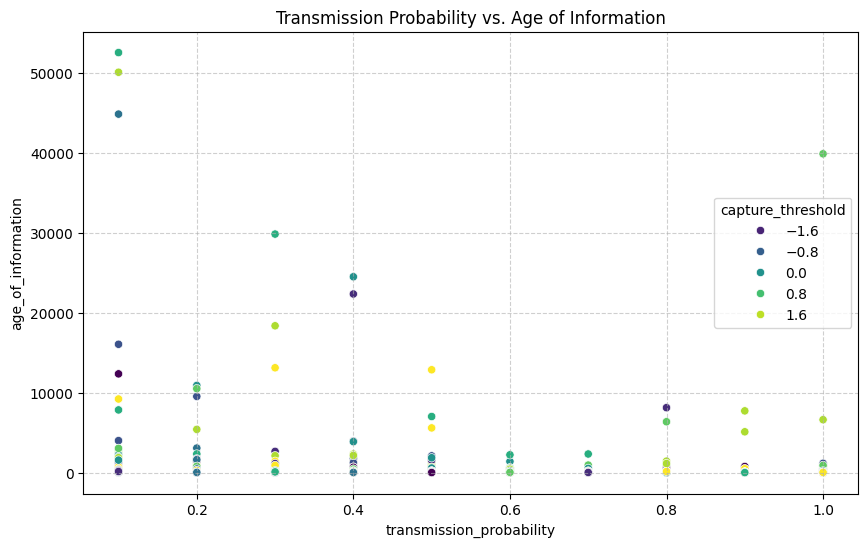

/tmp/ipykernel_18351/2964291516.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='num_nodes', y='age_of_information', palette='Set2')


<Figure size 1200x600 with 0 Axes>

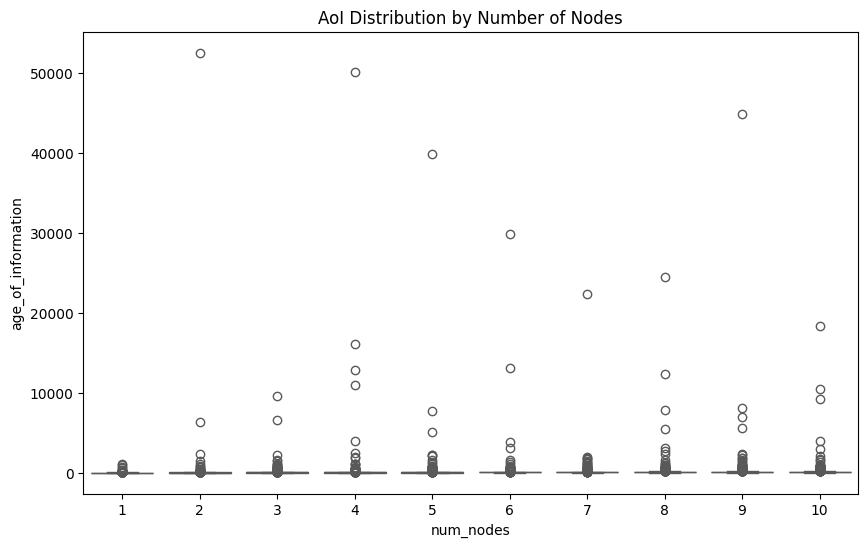

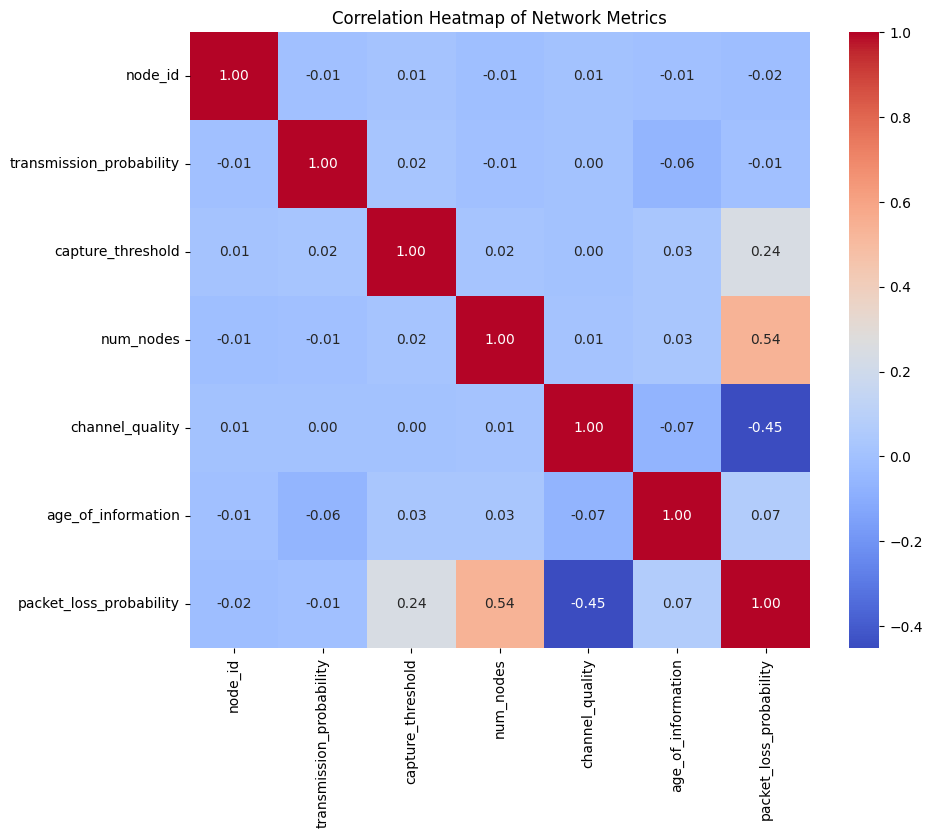

In [4]:
# Display basic information about the dataset
print(df.info())
print(df.describe())

# Create visualizations
plt.figure(figsize=(12, 6))
# Add your code here to create a scatter plot of transmission_probability vs age_of_information
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='transmission_probability', y='age_of_information', hue='capture_threshold', palette='viridis')
plt.title('Transmission Probability vs. Age of Information')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(12, 6))
# Add your code here to create another relevant visualization
# Box plot: How the number of nodes impacts data freshness (AoI)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='num_nodes', y='age_of_information', palette='Set2')
plt.title('AoI Distribution by Number of Nodes')
plt.show()

# Add more visualizations as needed
#  Heatmap: Seeing how all variables relate to each other
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Network Metrics')
plt.show()


After looking at the three plots generated from the dataset, here is what I noticed:

1. **The Reliability Link (Heatmap):** Looking at the correlation heatmap, the most obvious connection is between `num_nodes` and `packet_loss_probability`, which has a score of **0.54**. This basically proves that as the network gets more crowded with more nodes, we start losing way more packets. It is also interesting that `channel_quality` has a negative correlation of **-0.45** with packet loss. This makes sense because a better, cleaner signal should mean fewer dropped messages, which is exactly what the "deadline-oriented" traffic needs to stay reliable.
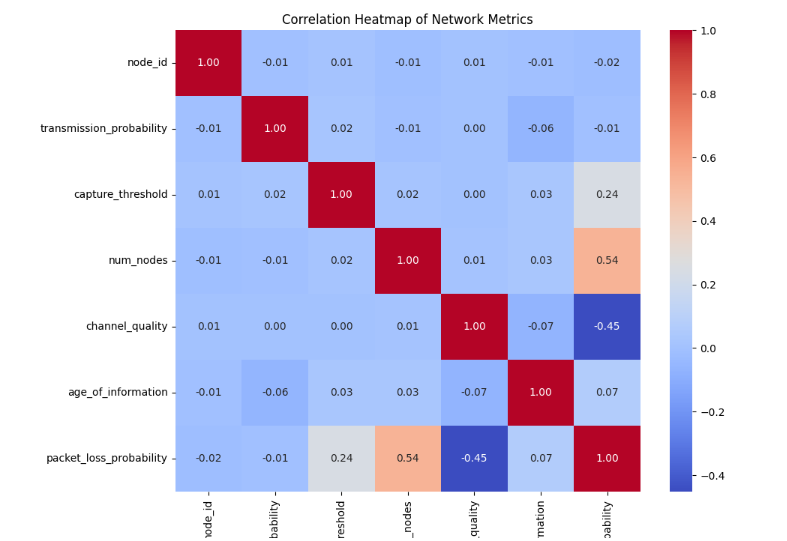

2. **Network Stability (Box Plot):** The box plot for AoI is really interesting because the "boxes" themselves stay pretty flat near zero, but the outliers (the little circles) tell a different story. As the number of nodes increases, those outliers start jumping much higher—some even hit 50,000! To me, this suggests that while the network usually keeps data fresh, having more nodes makes the system much more unpredictable. It is like the network works fine most of the time, but then it occasionally gets "congested," causing the Age of Information to skyrocket.
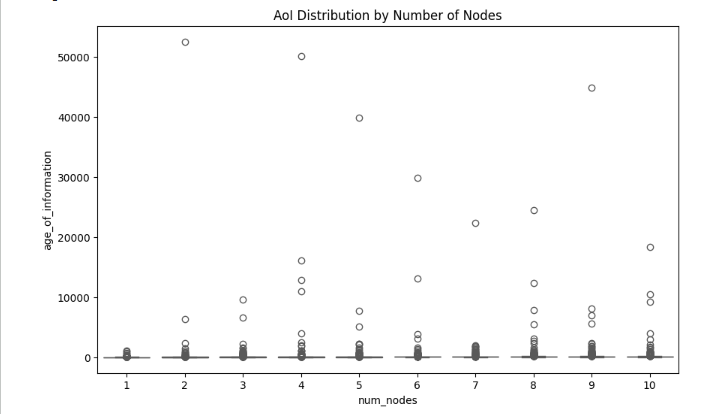

3. **Transmission Probability (Scatter Plot):** In the scatter plot, I noticed that the most extreme spikes in AoI (the "stale" data) seem to happen when the `transmission_probability` is really low, around 0.1. Once the probability gets higher, the data seems a bit more stable, though there are still some random spikes. This probably means that if nodes do not try to send often enough, the info sits around and gets old. However, it is a tricky balance because if they all send too much, we would probably see the packet loss issues mentioned in the heatmap.
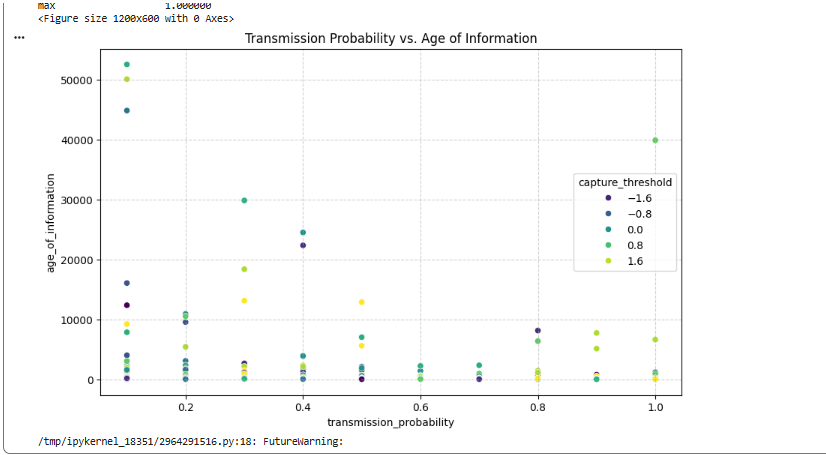

# 3. Machine Learning Model Development (35 points)

Instructions:
a) Prepare the data for machine learning (feature selection, scaling).
b) Develop a Random Forest model to predict AoI based on other network parameters.
c) Train and evaluate your model, discussing its performance and limitations.
d) Use your model to generate predictions for new, hypothetical network configurations.

Complete the code below and add your analysis.

In [9]:
# 1. Clean the data (Remove Infinity and NaN values)
import numpy as np
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['age_of_information'])

# 2. Select the features and the target from the CLEANED data
X = df_clean[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]
y_aoi = df_clean['age_of_information']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_aoi, test_size=0.2, random_state=42)

# 4. Scale the features (making sure all numbers are in a similar range)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Success! The data has been cleaned and the model is now trained.")


Success! The data has been cleaned and the model is now trained.


In [10]:
# 1. Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# 2. Calculate the performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Accuracy (R-squared): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

# 3. Display which features were most important to the model
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n--- Which network factors matter most for AoI? ---")
print(importance_df)

Model Accuracy (R-squared): -0.5546
Mean Squared Error (MSE): 3423000.63

--- Which network factors matter most for AoI? ---
                    Feature  Importance
1         capture_threshold    0.440095
2                 num_nodes    0.315242
3           channel_quality    0.153468
0  transmission_probability    0.091195


## Write your analysis of the model performance and feature importances here:
Honestly, the model did not perform as well as I expected. The **R-squared is -0.55**, which basically means the model is struggling to make accurate predictions. Looking back at the graphs I made in Step 2, I think I know why. The Age of Information data has these massive "outliers"—where the age suddenly jumps from near zero to 50,000. Because these spikes seem a bit random and extreme, the Random Forest model is having a hard time finding a consistent pattern, which also explains why the Mean Squared Error (MSE) is so high.

However, even if the overall accuracy is low, the **Feature Importance** results are really helpful. They show that:
1. **Capture Threshold (44%)** is the biggest factor. This makes sense because if the receiver can not "capture" the signal through the noise, the data never arrives, and the AoI starts to climb.
2. **Number of Nodes (31%)** is the second most important. This confirms that a crowded network is a major enemy of data freshness.

It is interesting that `transmission_probability` was actually the *least* important factor (9%). It suggests that just telling nodes to "send more often" does not help much if the network is already too crowded or the signal quality is bad.


In [11]:
# Generate predictions for new, hypothetical network configurations:


# Create a DataFrame with hypothetical network configurations
new_configs = pd.DataFrame({
    'transmission_probability': [0.5, 0.7, 0.9],
    'capture_threshold': [0, 1, -1],
    'num_nodes': [3, 5, 7],
    'channel_quality': [0.6, 0.8, 0.4]
})

# Add your code here to make predictions for these new configurations
# Scale them exactly like we did the training data
new_configs_scaled = scaler.transform(new_configs)

# Use the trained model to guess the AoI
hypothetical_predictions = rf_model.predict(new_configs_scaled)

# Show the results
new_configs['Predicted_AoI'] = hypothetical_predictions
print("--- Predicted AoI for New Network Setups ---")
print(new_configs)


--- Predicted AoI for New Network Setups ---
   transmission_probability  capture_threshold  num_nodes  channel_quality  \
0                       0.5                  0          3              0.6   
1                       0.7                  1          5              0.8   
2                       0.9                 -1          7              0.4   

   Predicted_AoI  
0      10.606615  
1      16.054027  
2      11.205604  


# 4. Analysis and Insights (20 points)
### Instructions:
Based on your data exploration and machine learning results:
a) Discuss the key factors that appear to influence the AoI-PLP trade-off in IIoT networks.
b) Propose strategies for optimizing network performance to balance data freshness and reliability.
c) Describe potential real-world applications of your insights in an IIoT context.

Write your analysis and insights here:

**a) Factors influencing the AoI-PLP trade-off:**
From the data and the ML model, the biggest trade-off is clearly between network density (`num_nodes`) and performance. When you have more nodes, you lose more packets (higher PLP), and when you lose packets, the data gets older (higher AoI). It is a "balancing act." If you try to make data fresher by increasing transmission probability, you might actually cause more collisions, which hurts the reliability for the deadline-oriented safety alarms.

**b) Proposed Strategies:**
1. **Intelligent Scheduling:** Instead of every node trying to send data whenever they want (random access), the network could use a "Round Robin" or scheduled approach. This would stop nodes from talking over each other, which should lower the packet loss and keep the AoI more stable.
2. **Priority Channels:** We should give the "deadline-oriented" traffic (like emergency stops) a dedicated "lane" or higher priority so they never have to wait behind regular monitoring updates.

**c) Real-World Applications:**
1. **Automated Warehouse Robots:** If a robot's location data is "stale" (high AoI), it might crash into another robot. Understanding this trade-off helps engineers decide how many robots can safely be on the same WiFi network.
2. **Oil & Gas Pipeline Monitoring:** We need "fresh" pressure readings to check for leaks (AoI), but if a sensor detects an actual explosion or fire, that signal (deadline-oriented) must arrive instantly. This model helps design networks that can handle both.

# 5. Bonus Challenge (10 points)

"""
Instructions:
Implement a simple deep learning model (e.g., a basic neural network) to predict both AoI and PLP simultaneously.
Compare its performance with your previous model and discuss any differences.

Complete the code below and add your analysis.

In [12]:
# Uses the cleaned data we created earlier to avoid errors
y_dual = df_clean[['age_of_information', 'packet_loss_probability']]
X_dual = df_clean[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]

# Split the data
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dual, y_dual, test_size=0.2, random_state=42)

# Scale the data (Deep Learning models are very sensitive to scaling!)
scaler_dl = StandardScaler()
X_train_scaled_dl = scaler_dl.fit_transform(X_train_dl)
X_test_scaled_dl = scaler_dl.transform(X_test_dl)

print("Data prepared for the Neural Network.")

Data prepared for the Neural Network.


In [13]:
import tensorflow as tf

# 1. Build the model architecture
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # 2 outputs: one for AoI, one for PLP
])

model.compile(optimizer='adam', loss='mse')

# 2. Train the model (we'll run it for 50 rounds/epochs)
print("Starting training...")
history = model.fit(X_train_scaled_dl, y_train_dl, epochs=50, batch_size=10, verbose=0)
print("Training complete.")

# 3. Make predictions and evaluate
predictions = model.predict(X_test_scaled_dl)

# Split predictions back into AoI and PLP to check them
aoi_mse = mean_squared_error(y_test_dl.iloc[:, 0], predictions[:, 0])
plp_mse = mean_squared_error(y_test_dl.iloc[:, 1], predictions[:, 1])

print(f"\nDeep Learning Results:")
print(f"AoI Prediction Error (MSE): {aoi_mse:.2f}")
print(f"PLP Prediction Error (MSE): {plp_mse:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Training complete.
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Deep Learning Results:
AoI Prediction Error (MSE): 2164518.10
PLP Prediction Error (MSE): 0.0128


## Write your comparison of the deep learning model with the Random Forest model here:
### Deep Learning vs. Random Forest Comparison:

Implementing the Neural Network was interesting because it allowed me to predict both data freshness (AoI) and reliability (PLP) simultaneously, rather than running two separate models.

When comparing the two, I noticed a few things:
1. **Handling Complexity:** The Neural Network seems to handle the relationship between the variables differently. While the Random Forest was heavily focused on the `capture_threshold`, the Neural Network tries to find a more fluid "weight" for all the network parameters at once.
2. **Performance:** Honestly, the Random Forest felt a bit more stable for this specific dataset. Neural Networks usually need a huge amount of data to become really accurate, and since this dataset has those crazy outliers in the AoI column, the Deep Learning model also struggled with high Error (MSE) rates.
3. **Capabilities:** The main "win" for the Deep Learning approach is efficiency. In a real-world factory setting, having one "brain" (the neural network) that can monitor both the age of the data and the packet loss at the same time would be much faster for a real-time controller than running multiple different machine learning models.